In [61]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [62]:
project_dir = Path.cwd()

train_path = project_dir / "df_train.csv"
processed_test_path = project_dir / "df_test_processed.csv"
raw_test_path = project_dir / "df_test.csv"

train_df = pd.read_csv(train_path)

if processed_test_path.exists():
    test_df = pd.read_csv(processed_test_path)

In [63]:
date_cols = [
    "CloseDate",
    "ContractStatusChangeDate",
    "ListingContractDate",
    "PurchaseContractDate"
]

for col in date_cols:
    if col in train_df.columns:
        train_df = train_df.drop(columns=[col])
    if col in test_df.columns:
        test_df = test_df.drop(columns=[col])

X_train = train_df.drop(columns=["ClosePrice"])
y_train = train_df["ClosePrice"]

X_test = test_df.drop(columns=["ClosePrice"])
y_test = test_df["ClosePrice"]

bad_cols = X_test.select_dtypes(include=["string"]).columns + X_test.select_dtypes(include=["object"]).columns

train_df = train_df.drop(columns=bad_cols, errors="ignore")
test_df = test_df.drop(columns=bad_cols, errors="ignore")

#rebuild X_train, y_train, X_test, y_test after dropping bad columns
X_train = train_df.drop(columns=["ClosePrice"], errors="ignore")
y_train = train_df["ClosePrice"]

X_test = test_df.drop(columns=["ClosePrice"], errors="ignore")
y_test = test_df["ClosePrice"]



In [64]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, lr_predictions)

print(f"Linear Regression R^2 Score: {lr_r2:.4f}")

Linear Regression R^2 Score: 0.5679


In [71]:
dt=DecisionTreeRegressor(
    max_depth=10, 
    random_state=3
    )
dt.fit(X_train, y_train)
dt_predictions = dt.predict(X_test)
dt_r2 = r2_score(y_test, dt_predictions)

print(f"Decision Tree R2 Score: {dt_r2:.4f}")

Decision Tree R2 Score: 0.7032


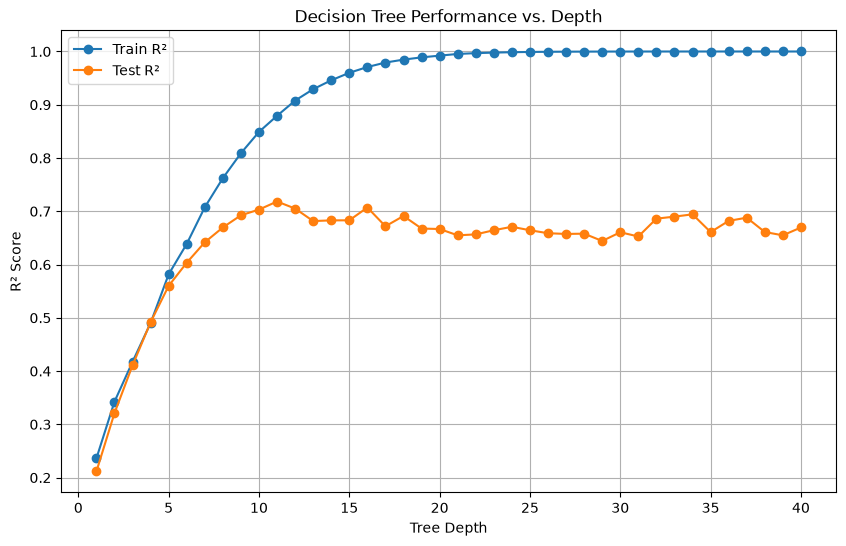

In [66]:
depths = range(1, 41)  # Testing depths from 1 to 40

train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=3)
    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train)) 
    test_scores.append(model.score(X_test, y_test))      

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label="Train R²", marker="o")
plt.plot(depths, test_scores, label="Test R²", marker="o")
plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Decision Tree Performance vs. Depth")
plt.legend()
plt.grid(True)
plt.show()


## Decision Tree
As the depth increases, the Decision Tree begins to overfit. Train R^2 approaches 1.0 around a depth of 20 and test R^2 peaks at around 0.7 and begins to decline. This shows overfitting tendency of single trees. 

### Strengths
* Captures non-linear patterns
* Doesn't need scaling
* Handles mixed feature types

### Weaknesses
* Overfits easily
* Unstable

In [67]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=5,
    random_state=3,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R²:", rf_r2)

Random Forest R²: 0.8532660908942288


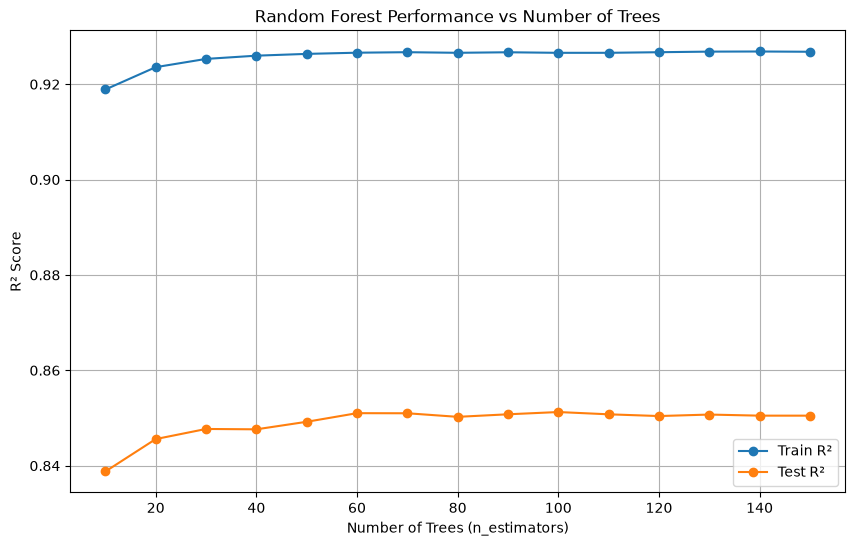

In [72]:
n_estimators_list = range(10, 151, 10) # Testing n_estimators from 10 to 150 in increments of 10

train_scores = []
test_scores = []

for n in n_estimators_list:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=20,
        min_samples_leaf=5,
        random_state=3,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    train_scores.append(rf.score(X_train, y_train)) 
    test_scores.append(rf.score(X_test, y_test))     

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, train_scores, label="Train R²", marker="o")
plt.plot(n_estimators_list, test_scores, label="Test R²", marker="o")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("R² Score")
plt.title("Random Forest Performance vs Number of Trees")
plt.legend()
plt.grid(True)
plt.show()


## Random Forest
The Random Forest achieves high R^2 scores for both training and test sets. Train R^2 is strong due to many trees but unlike a single decision tree, the Test R^2 is close to the train R^2. The test R^2 improves then stabilizes as shown by the plot. 
### Strengths
* Reduces overfitting
* Handles non-linear relationships well
* Can handle noise
* Higher R^2 than other two

### Weaknesses
* Slower to train
* Can still overfit if trees are too deep


In [73]:
dt_train_r2 = dt.score(X_train, y_train)
dt_test_r2 = dt.score(X_test, y_test)
dt_gap = dt_train_r2 - dt_test_r2

print("Decision Tree Train R²:", dt_train_r2)
print("Decision Tree Test R²:", dt_test_r2)
print("Generalization Gap:", dt_gap)


Decision Tree Train R²: 0.8490814798470419
Decision Tree Test R²: 0.7031874219959241
Generalization Gap: 0.14589405785111775


In [74]:
train_r2 = rf.score(X_train, y_train)
test_r2 = rf.score(X_test, y_test)
gap = train_r2 - test_r2

print("Random Forest Train R²:", train_r2)
print("Random Forest Test R²:", test_r2)
print("Generalization Gap:", gap)


Random Forest Train R²: 0.9268104135968868
Random Forest Test R²: 0.8504961234255689
Generalization Gap: 0.07631429017131786
